## Gradiente Descendente

Seja $J(\Theta)$ uma função objetivo tal que
$$
J : \mathbb{R}^{n} \rightarrow \mathbb{R},
$$
onde $\Theta \in \mathbb{R}^{n}$ representa o vetor de parâmetros.

O método do gradiente descendente é um algoritmo iterativo definido por:

$$
\Theta^{(t+1)} = \Theta^{(t)} - \eta \nabla J\!\left(\Theta^{(t)}\right),
$$

onde $\eta$ é a taxa de aprendizado e $\nabla J(\Theta)$ é o vetor gradiente.

O objetivo do algoritmo é gerar uma sequência $\{\Theta^{(t)}\}_{t \ge 0}$
que converge para um ponto que minimiza a função $J$.

## Exemplo prático

Considere a função abaixo

$$
f(x, y) = x^{2} + 2y^{2},
$$

e queremos encontrar o ponto $(x, y)$ que minimiza $f$.

O gradiente é o vetor das derivadas parciais:

$$
\nabla f(x, y) =
\left(
\frac{\partial f}{\partial x},
\frac{\partial f}{\partial y}
\right)
$$

Calculando,

$$
\frac{\partial f}{\partial x} = 2x,
\qquad
\frac{\partial f}{\partial y} = 4y
$$

Logo,
$$
\nabla f(x, y) = (2x,\; 4y)
$$


Seja $(x^{(t)}, y^{(t)})$ o ponto na iteração $t$ e $\eta > 0$ a taxa de aprendizado. A atualização vetorial é:

$$
\begin{pmatrix}
x^{(t+1)} \\
y^{(t+1)}
\end{pmatrix}
=
\begin{pmatrix}
x^{(t)} \\
y^{(t)}
\end{pmatrix}
-
\eta
\begin{pmatrix}
2x^{(t)} \\
4y^{(t)}
\end{pmatrix}
$$

### Implementação do exemplo prático

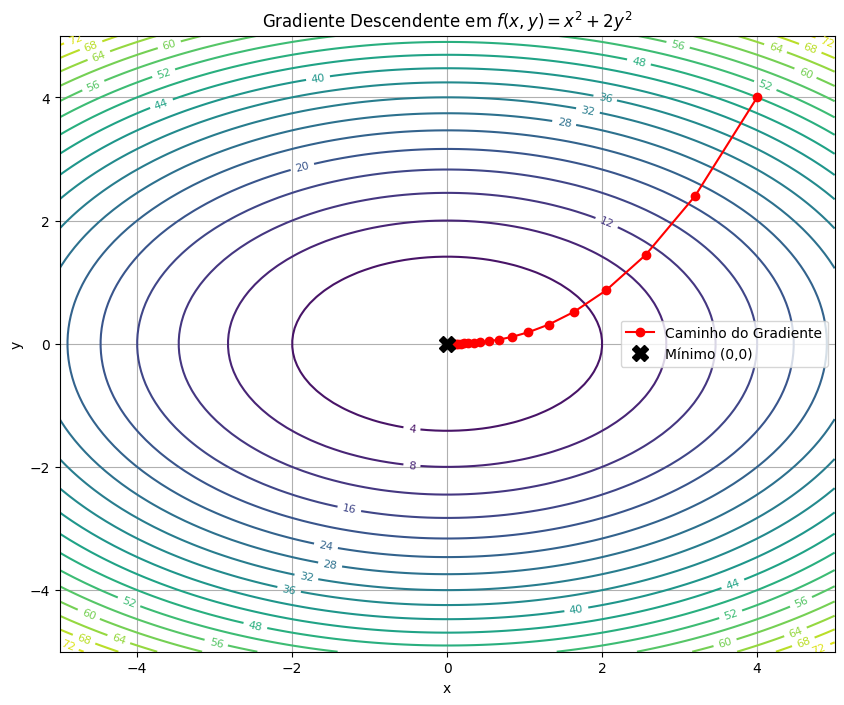

In [6]:
import numpy as np
import matplotlib.pyplot as plt

def f(x, y):
    return x**2 + 2*y**2

def gradient(x, y):
    df_dx = 2 * x
    df_dy = 4 * y
    return np.array([df_dx, df_dy])

alpha = 0.1
iterations = 20
start_point = [4, 4]

history = [start_point]
current_pos = np.array(start_point)

for i in range(iterations):
    grad = gradient(current_pos[0], current_pos[1])
    current_pos = current_pos - alpha * grad
    history.append(current_pos)

history = np.array(history)

x_range = np.linspace(-5, 5, 100)
y_range = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x_range, y_range)
Z = f(X, Y)

plt.figure(figsize=(10, 8))

contours = plt.contour(X, Y, Z, levels=20, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

plt.plot(history[:, 0], history[:, 1], '-o', color='red', label='Caminho do Gradiente')
plt.plot(0, 0, 'X', color='black', markersize=12, label='Mínimo (0,0)')

plt.title(f'Gradiente Descendente em $f(x, y) = x^2 + 2y^2$')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True)
plt.show()